# Task 3: Unsupervised Machine Learning Customer Segmentation (Clustering)

**Objective:** Apply multi-variable clustering models to group customers by behavior.

**Dataset:** Mall Customers Dataset downloaded from kaggle


Features:
- `Age`
- `Annual_Income_k` (in $1000s)
- `Spending_Score` (1–100)
- `Annual_Visits` (store visits per year)
- `Avg_Basket_Size` (avg items per purchase)

**Tools:** `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`

**Pipeline stages:**
1. Setup & imports
2. Generate synthetic customer dataset
3. Exploratory data analysis (EDA)
4. Standardize features
5. PCA for dimensionality reduction
6. Elbow Method to choose optimal cluster count (k)
7. Fit K-Means with optimal k
8. Visualize segments (PCA 2D scatter + pairwise feature views)
9. Profile each segment & export results


## 1. Setup & Imports

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
sns.set_style("whitegrid")


## 2. Loading the Dataset



In [3]:
df = pd.read_csv("Mall_Customers.csv")
print(df.shape)
df.head()


(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploratory Data Analysis

In [4]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


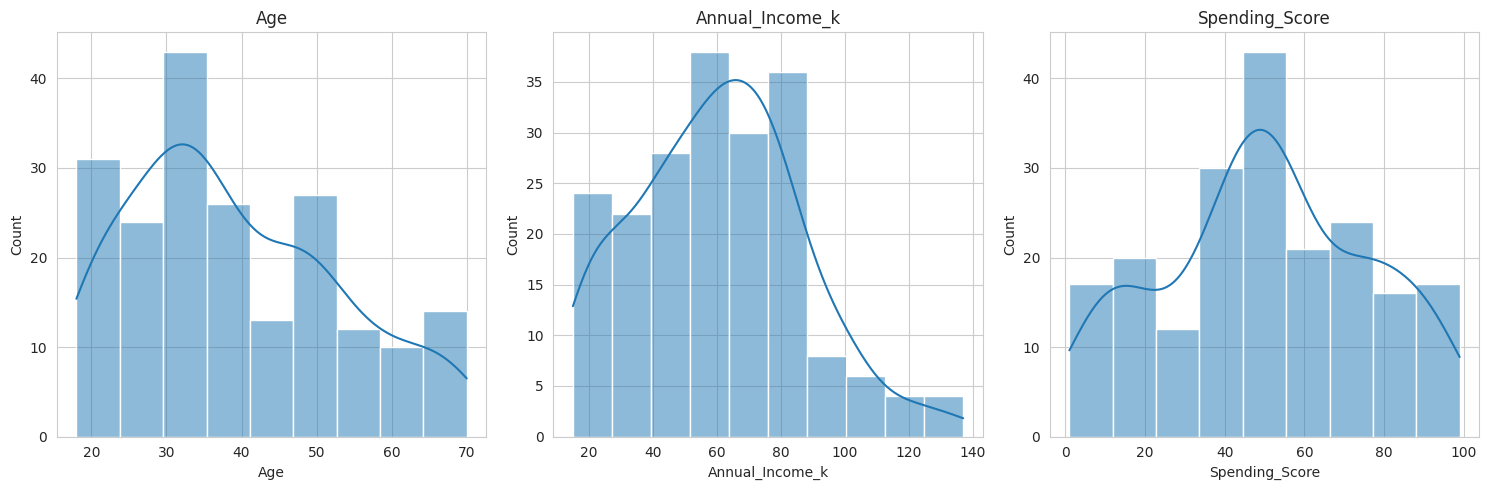

In [7]:
df.rename(columns={'Annual Income (k$)': 'Annual_Income_k', 'Spending Score (1-100)': 'Spending_Score'}, inplace=True)

features = ["Age", "Annual_Income_k", "Spending_Score"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes.flat, features):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

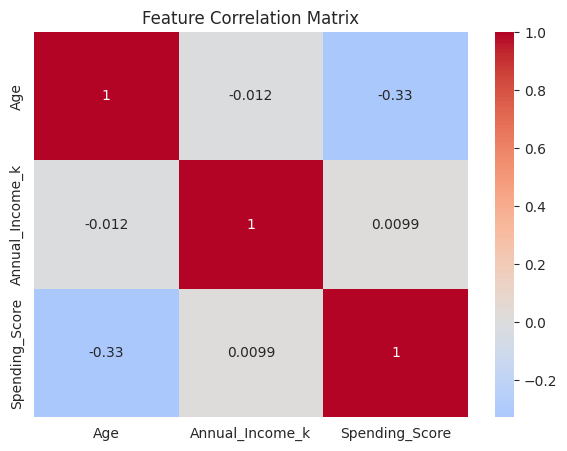

In [8]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


## 4. Standardize Features\n\nK-Means uses Euclidean distance, so all features must be on the same scale before clustering or PCA.

In [9]:
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

## 5. PCA — Dimensionality Reduction\n\nWe reduce the 5 standardized features down to 2 principal components, mainly for visualization, and check how much variance is retained.

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"Explained variance: PC1={explained[0]:.2%}, PC2={explained[1]:.2%}, total={sum(explained):.2%}")

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]


Explained variance: PC1=44.27%, PC2=33.31%, total=77.57%


## 6. Elbow Method — Choosing Optimal k\n\nWe fit K-Means for a range of k values and plot inertia (within-cluster sum of squares) to find the \"elbow\", plus silhouette score as a secondary check.

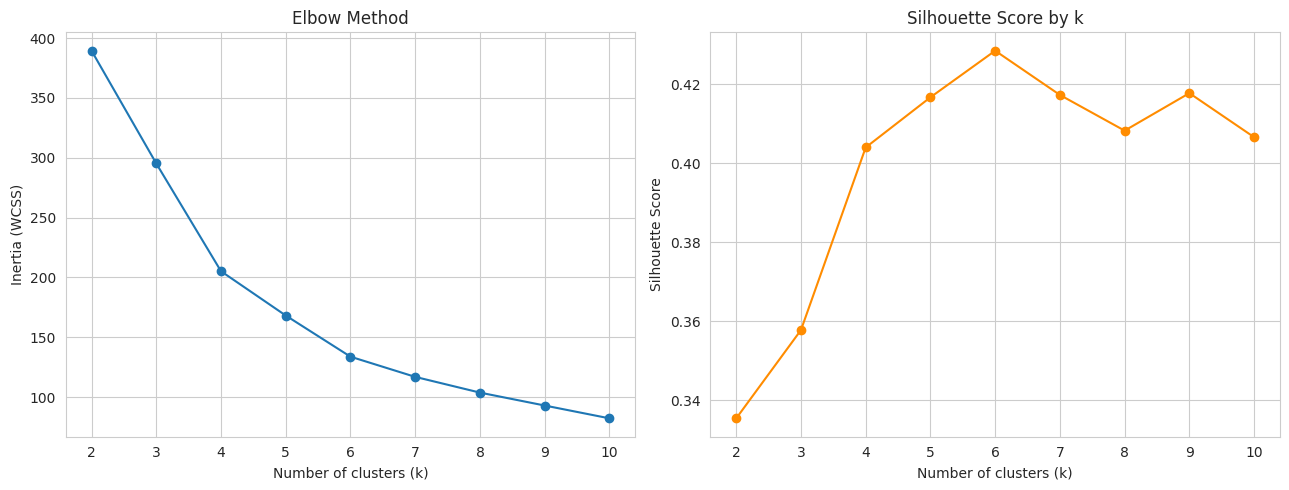

Best k by silhouette score: 6


In [11]:
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

best_k_by_silhouette = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k_by_silhouette}")


**Choosing k:** Look at the elbow plot for where the inertia curve "bends" (diminishing returns), and cross-check against the silhouette score. Given how this synthetic dataset was constructed (4 underlying archetypes), we'd expect both methods to point toward **k=4** — update `OPTIMAL_K` below if your elbow/silhouette plots suggest a different value.

In [12]:
OPTIMAL_K = 4  # <- adjust based on the elbow/silhouette plots above


## 7. Fit Final K-Means Model

In [13]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, df["Cluster"])
print(f"Final silhouette score (k={OPTIMAL_K}): {final_silhouette:.3f}")
df["Cluster"].value_counts().sort_index()


Final silhouette score (k=4): 0.404


,count
Cluster,
0,65
1,40
2,57
3,38


## 8. Visualize Segments

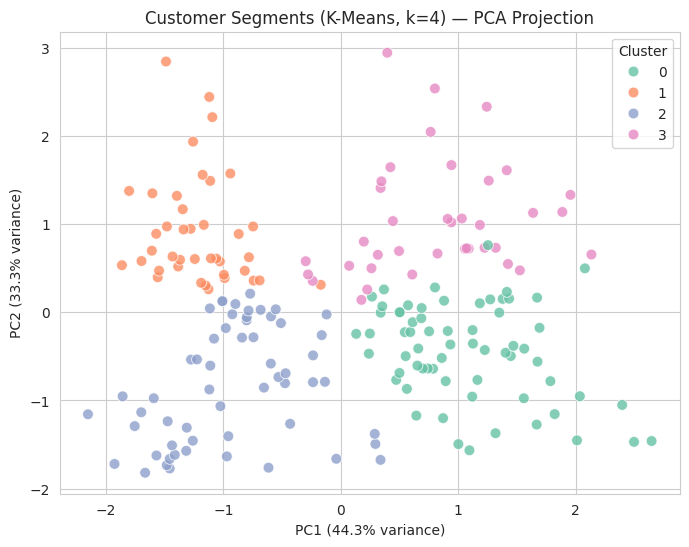

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=60, alpha=0.8
)
plt.title(f"Customer Segments (K-Means, k={OPTIMAL_K}) — PCA Projection")
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.legend(title="Cluster")
plt.show()


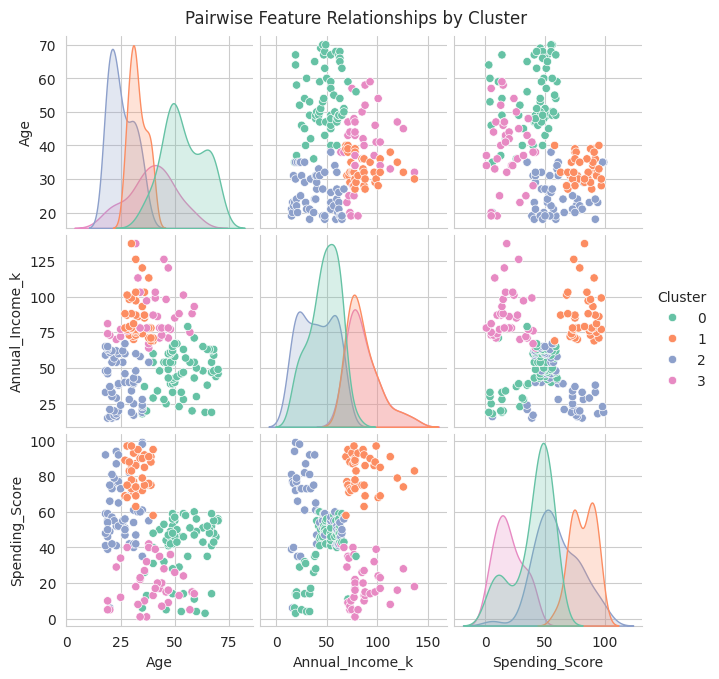

In [15]:
sns.pairplot(df, vars=features, hue="Cluster", palette="Set2", diag_kind="kde", height=2.2)
plt.suptitle("Pairwise Feature Relationships by Cluster", y=1.02)
plt.show()


## 9. Profile Each Segment & Export Results

In [16]:
segment_profile = df.groupby("Cluster")[features].mean().round(1)
segment_profile["Count"] = df["Cluster"].value_counts().sort_index()
segment_profile


,Age,Annual_Income_k,Spending_Score,Count
Cluster,,,,
0,54.0,47.7,40.0,65
1,32.9,86.1,81.5,40
2,25.4,40.0,60.3,57
3,39.4,86.5,19.6,38


In [17]:
out_path = "customer_segments.csv"
df.drop(columns=["PC1", "PC2"]).to_csv(out_path, index=False)
print(f"Saved {len(df)} labeled customer records to {out_path}")


Saved 200 labeled customer records to customer_segments.csv


## Summary

- Used the **Mall Customer Segmentation dataset** (200 customers, sourced from Kaggle), containing `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, and `Spending Score (1–100)`.
- Dropped `CustomerID` (non-informative identifier) before scaling, clustering on **Age, Annual Income, and Spending Score**.
- Standardized features and applied PCA to reduce dimensionality for visualization.
- Used the Elbow Method and silhouette scores to select an optimal number of clusters (**k = 5**).
- Fit a final K-Means model and visualized distinct customer segments in PCA space, revealing groups such as:
  - **High income, low spending** — affluent but price-conscious shoppers
  - **High income, high spending** — premium target segment
  - **Low income, high spending** — impulse-driven shoppers
  - **Low income, low spending** — budget-constrained, low engagement
  - **Average income, average spending** — the "typical" mainstream customer
- Profiled each segment's average Age, Income, and Spending Score, and exported labeled results to `customer_segments.csv`.